## Memprediksi Curah Hujan Esok Hari dengan Menggunakan Algoritma K-Nearest Neighbors (K-NN) 

In [1]:
# import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
# read dataset iklim kelompok D
df = pd.read_csv('DF Kelompok D.csv')
df

,Tanggal,Arah Angin Saat Kec Maks,Arah Angin Terbanyak,Kec Angin Maks,Kec Angin Rata-rata,Kelembaban,Lamanya Penyinaran,Temp Maks,Temp Min,Temp Rata-rata,Curah Hujan
0,43466,250.0,W,4.0,3.0,88.0,2.1,30.0,22.2,25.4,16.1
1,43467,280.0,W,5.0,3.0,81.0,0.1,32.6,22.4,27.3,1.0
2,43468,260.0,W,6.0,4.0,76.0,4.9,33.2,22.4,27.4,4.5
3,43469,280.0,SW,6.0,3.0,73.0,8.4,34.2,22.6,28.7,NaN
4,43470,90.0,SW,3.0,2.0,76.0,9.7,33.4,23.4,28.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
726,44192,240.0,SW,4.0,2.0,74.0,5.7,33.7,NaN,29.0,0.0
727,44193,240.0,SW,5.0,3.0,77.0,6.8,32.8,25.4,28.1,NaN
728,44194,240.0,SW,7.0,3.0,82.0,6.1,30.8,24.8,27.1,0.1
729,44195,260.0,W,4.0,2.0,81.0,1.4,30.8,24.6,27.0,0.3


In [3]:
# menghapus kolom yang tidak dipakai sebagai feature dan target
df = df.drop(['Tanggal', 'Arah Angin Saat Kec Maks', 
              'Arah Angin Terbanyak', 'Kec Angin Maks', 
              'Kec Angin Rata-rata', 'Temp Rata-rata'], axis = 1)
#kelembaban, lamanya penyinaran, temp maks, temp min, curah hujan adalah feature
df

,Kelembaban,Lamanya Penyinaran,Temp Maks,Temp Min,Curah Hujan
0,88.0,2.1,30.0,22.2,16.1
1,81.0,0.1,32.6,22.4,1.0
2,76.0,4.9,33.2,22.4,4.5
3,73.0,8.4,34.2,22.6,NaN
4,76.0,9.7,33.4,23.4,NaN
...,...,...,...,...,...
726,74.0,5.7,33.7,NaN,0.0
727,77.0,6.8,32.8,25.4,NaN
728,82.0,6.1,30.8,24.8,0.1
729,81.0,1.4,30.8,24.6,0.3


In [4]:
# periksa baris yang mengandung outliers pada kolom Kelembaban (persentase)
for n in range(0, 730) :
    if df.at[n, 'Kelembaban'] > 100 :
        df.at[n, 'Kelembaban'] = np.nan
        
# periksa baris yang mengandung outliers pada kolom Lamanya Penyinaran (Jam)
for n in range(0, 730) :
    if df.at[n, 'Lamanya Penyinaran'] > 12 :
        df.at[n, 'Lamanya Penyinaran'] = np.nan
        
# periksa baris yang mengandung outliers pada Temp Maks (Celcius)
for n in range(0, 730) :
    if df.at[n, 'Temp Maks'] > 50 :
        df.at[n, 'Temp Maks'] = np.nan
        
# periksa baris yang mengandung outliers pada Temp Min (Celcius)
for n in range(0, 730) :
    if df.at[n, 'Temp Min'] > 50 :
        df.at[n, 'Temp Min'] = np.nan
        
# periksa baris yang mengandung outliers pada kolom Curah Hujan (milimeter)
for n in range(0, 730) :
    if df.at[n, 'Curah Hujan'] > 380 : # berdasarkan berita, Jakarta pernah mengalami curah hujan 377 mm/hari pada tahun 2020
        df.at[n, 'Curah Hujan'] = np.nan
    

In [5]:
# menghapus baris NaN pada dataframe
df = df.dropna()
df

,Kelembaban,Lamanya Penyinaran,Temp Maks,Temp Min,Curah Hujan
0,88.0,2.1,30.0,22.2,16.1
1,81.0,0.1,32.6,22.4,1.0
2,76.0,4.9,33.2,22.4,4.5
5,79.0,5.9,33.5,23.3,46.0
8,84.0,6.0,32.0,23.3,3.5
...,...,...,...,...,...
722,77.0,2.0,34.0,24.2,0.3
725,74.0,7.2,33.8,24.2,0.1
728,82.0,6.1,30.8,24.8,0.1
729,81.0,1.4,30.8,24.6,0.3


In [6]:
# reset index dataframe agar tidak bingung
df = df.reset_index(drop=True)
df

,Kelembaban,Lamanya Penyinaran,Temp Maks,Temp Min,Curah Hujan
0,88.0,2.1,30.0,22.2,16.1
1,81.0,0.1,32.6,22.4,1.0
2,76.0,4.9,33.2,22.4,4.5
3,79.0,5.9,33.5,23.3,46.0
4,84.0,6.0,32.0,23.3,3.5
...,...,...,...,...,...
378,77.0,2.0,34.0,24.2,0.3
379,74.0,7.2,33.8,24.2,0.1
380,82.0,6.1,30.8,24.8,0.1
381,81.0,1.4,30.8,24.6,0.3


In [7]:
# membuat kolom Curah Hujan d+1 pada dataframe sebagai target K-NN
df['Curah Hujan d+1'] = 0

for i in range (df.shape[0]-1) :
    df.iloc[i,5] = df.iloc[i+1,4]
    
df

,Kelembaban,Lamanya Penyinaran,Temp Maks,Temp Min,Curah Hujan,Curah Hujan d+1
0,88.0,2.1,30.0,22.2,16.1,1.0
1,81.0,0.1,32.6,22.4,1.0,4.5
2,76.0,4.9,33.2,22.4,4.5,46.0
3,79.0,5.9,33.5,23.3,46.0,3.5
4,84.0,6.0,32.0,23.3,3.5,16.6
...,...,...,...,...,...,...
378,77.0,2.0,34.0,24.2,0.3,0.1
379,74.0,7.2,33.8,24.2,0.1,0.1
380,82.0,6.1,30.8,24.8,0.1,0.3
381,81.0,1.4,30.8,24.6,0.3,0.5


In [8]:
# persiapan pembuatan variabel untuk rumus normalisasi data

# Max, Min, Delta Kelembaban
lembab_max = df['Kelembaban'].max()
lembab_min = df['Kelembaban'].min()
lembab_delta = lembab_max - lembab_min

# Max, Min, Delta Lamanya Penyinaran
sinar_max = df['Lamanya Penyinaran'].max()
sinar_min = df['Lamanya Penyinaran'].min()
sinar_delta = sinar_max - sinar_min

# Max, Min, Delta Temp Maks
tmpMaks_max = df['Temp Maks'].max()
tmpMaks_min = df['Temp Maks'].min()
tmpMaks_delta = tmpMaks_max - tmpMaks_min

# Max, Min, Delta Temp Min
tmpMin_max = df['Temp Min'].max()
tmpMin_min = df['Temp Min'].min()
tmpMin_delta = tmpMin_max - tmpMin_min

# Max, Min, Delta Curah Hujan
curah_max = df['Curah Hujan'].max()
curah_min = df['Curah Hujan'].min()
curah_delta = curah_max - curah_min

# Max, Min, Delta Curah Hujan
curahD1_max = df['Curah Hujan d+1'].max()
curahD1_min = df['Curah Hujan d+1'].min()
curahD1_delta = curahD1_max - curahD1_min

In [9]:
# Normalisasi semua data  
for i in range (df.shape[0]) : # rumus: y - y_min / delta_y
    df.iloc[i,0] = (df.iloc[i,0] - lembab_min) / lembab_delta
    df.iloc[i,1] = (df.iloc[i,1] - sinar_min) / sinar_delta
    df.iloc[i,2] = (df.iloc[i,2] - tmpMaks_min) / tmpMaks_delta
    df.iloc[i,3] = (df.iloc[i,3] - tmpMin_min) / tmpMin_delta
    df.iloc[i,4] = (df.iloc[i,4] - curah_min) / curah_delta
    df.iloc[i,5] = (df.iloc[i,5] - curahD1_min) / curahD1_delta

df

,Kelembaban,Lamanya Penyinaran,Temp Maks,Temp Min,Curah Hujan,Curah Hujan d+1
0,0.756098,0.200000,0.294118,0.172414,0.077070,0.004787
1,0.585366,0.009524,0.549020,0.206897,0.004787,0.021541
2,0.463415,0.466667,0.607843,0.206897,0.021541,0.220201
3,0.536585,0.561905,0.637255,0.362069,0.220201,0.016754
4,0.658537,0.571429,0.490196,0.362069,0.016754,0.079464
...,...,...,...,...,...,...
378,0.487805,0.190476,0.686275,0.517241,0.001436,0.000479
379,0.414634,0.685714,0.666667,0.517241,0.000479,0.000479
380,0.609756,0.580952,0.372549,0.620690,0.000479,0.001436
381,0.585366,0.133333,0.372549,0.586207,0.001436,0.002393


In [10]:
# pembagian data latih (train) dan data uji (test)

data_train = df.iloc[:-10] # semua data kecuali 10 data terakhir

# data test diambil dari 10 data terakhir yang ada di dataframe
data_test = df.tail(10)


In [11]:
# cetak data_train
data_train

,Kelembaban,Lamanya Penyinaran,Temp Maks,Temp Min,Curah Hujan,Curah Hujan d+1
0,0.756098,0.200000,0.294118,0.172414,0.077070,0.004787
1,0.585366,0.009524,0.549020,0.206897,0.004787,0.021541
2,0.463415,0.466667,0.607843,0.206897,0.021541,0.220201
3,0.536585,0.561905,0.637255,0.362069,0.220201,0.016754
4,0.658537,0.571429,0.490196,0.362069,0.016754,0.079464
...,...,...,...,...,...,...
368,0.634146,0.009524,0.333333,0.379310,0.071326,0.006223
369,0.756098,0.666667,0.392157,0.586207,0.006223,0.009574
370,0.658537,0.428571,0.392157,0.655172,0.009574,0.004787
371,0.609756,0.352381,0.431373,0.655172,0.004787,0.007180


In [12]:
# cetak data test
data_test

,Kelembaban,Lamanya Penyinaran,Temp Maks,Temp Min,Curah Hujan,Curah Hujan d+1
373,0.560976,0.123810,0.490196,0.551724,0.052657,0.000000
374,0.585366,0.209524,0.490196,0.551724,0.000000,0.032551
375,0.634146,0.266667,0.372549,0.379310,0.032551,0.001915
376,0.634146,0.257143,0.254902,0.517241,0.001915,0.000000
377,0.560976,0.019048,0.450980,0.517241,0.000000,0.001436
378,0.487805,0.190476,0.686275,0.517241,0.001436,0.000479
379,0.414634,0.685714,0.666667,0.517241,0.000479,0.000479
380,0.609756,0.580952,0.372549,0.620690,0.000479,0.001436
381,0.585366,0.133333,0.372549,0.586207,0.001436,0.002393
382,0.756098,0.009524,0.274510,0.551724,0.002393,0.000000


### Persiapan K-NN

In [13]:
# membuat dataframe untuk menyimpan nilai euclidean
euclidean = pd.DataFrame(index=range(0,273),columns=['Euclidean'])
euclidean['Euclidean'] = np.nan
# membuat kolom untuk menyimpan data prediksi pada dataframe
data_test['Curah Hujan Prediksi'] = 0

# menghitung nilai euclidean
for i in range (0, 10) :
    for j in range (0, 273) :
        # rumus euclidean distance
        euclidean.iloc[j] = np.sqrt(((data_test.iloc[i,0] - data_train.iloc[j,0])**2) + 
                                ((data_test.iloc[i,1] - data_train.iloc[j,1])**2) + 
                                ((data_test.iloc[i,2] - data_train.iloc[j,2])**2) + 
                                ((data_test.iloc[i,3] - data_train.iloc[j,3])**2) + 
                                ((data_test.iloc[i,4] - data_train.iloc[j,4])**2))
        euclidean['Curah Hujan d+1'] = data_train['Curah Hujan d+1']
        # mengurutkan 5 nilai euclidean terkecil 
        euclidean = euclidean.sort_values(by=['Euclidean'])
        k5 = euclidean.head(5)
        # menghitung rata-rata 5 euclidean terkecil untuk mendapatkan nilai prediksi
        k5 = k5['Curah Hujan d+1'].mean()
        # masukan hasil prediksi ke dataframe
        data_test.iloc[i,6] = k5

In [14]:
# cetak dataframe data_test untuk melihat curah hujan hasil prediksi dan curah hujan data riil
data_test[['Curah Hujan d+1','Curah Hujan Prediksi']]

,Curah Hujan d+1,Curah Hujan Prediksi
373,0.000000,0.216084
374,0.032551,0.226041
375,0.001915,0.018478
376,0.000000,0.006989
377,0.001436,0.001915
378,0.000479,0.023169
379,0.000479,0.082240
380,0.001436,0.029488
381,0.002393,0.042413
382,0.000000,0.034562


In [15]:
# menghitung RMSE antara hasil prediksi dan data riil
data_test['RMSE'] = 0
for i in range (0,10) :
    data_test.iloc[i,7] = np.sqrt((data_test.iloc[i,5] - data_test.iloc[i,6])**2) # rumus RMSE

In [16]:
# melihat RMSE perbaris
data_test[['Curah Hujan d+1','Curah Hujan Prediksi','RMSE']]

,Curah Hujan d+1,Curah Hujan Prediksi,RMSE
373,0.000000,0.216084,0.216084
374,0.032551,0.226041,0.193490
375,0.001915,0.018478,0.016563
376,0.000000,0.006989,0.006989
377,0.001436,0.001915,0.000479
378,0.000479,0.023169,0.022690
379,0.000479,0.082240,0.081762
380,0.001436,0.029488,0.028052
381,0.002393,0.042413,0.040019
382,0.000000,0.034562,0.034562


In [17]:
# menghitung average RMSE antara Data Curah Hujan Riil dan Curah Hujan Prediksi
avg_rmse = data_test['RMSE'].mean()

print('Hasil Average RMSE Data Test :', avg_rmse)

Hasil Average RMSE Data Test : 0.06406893250359023


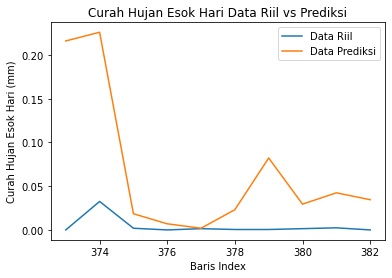

In [18]:
# visualisasi data antara prediksi curah hujan esok hari dan data riil
plt.plot(data_test['Curah Hujan d+1'], label='Data Riil')
plt.plot(data_test['Curah Hujan Prediksi'], label='Data Prediksi')
plt.legend()
plt.ylabel('Curah Hujan Esok Hari (mm)')
plt.xlabel('Baris Index')
plt.title("Curah Hujan Esok Hari Data Riil vs Prediksi")
plt.show()

In [19]:
# denormalisasi data Prediksi Curah Hujan Esok Hari
for i in range (0, 10) : # rumus y_min + y * delta_y
    data_test.iloc[i,6] = curahD1_min + data_test.iloc[i,6] * curahD1_delta
    data_test.iloc[i,5] = curahD1_min + data_test.iloc[i,5] * curahD1_delta

In [20]:
data_test[['Curah Hujan d+1', 'Curah Hujan Prediksi']]

,Curah Hujan d+1,Curah Hujan Prediksi
373,0.0,45.14
374,6.8,47.22
375,0.4,3.86
376,0.0,1.46
377,0.3,0.40
378,0.1,4.84
379,0.1,17.18
380,0.3,6.16
381,0.5,8.86
382,0.0,7.22


#### Kesimpulannya : Algoritma K-NN tidak cukup baik untuk prediksi pada kasus ini. Karena jika dilihat hasil dari prediksi sangat jauh berbeda dengan data riil, dari 10 data uji hanya terdapat 1 data saja yang prediksinya mendekati data riil yaitu pada data ke 5 dengan data riil 0,3 dan data prediksi 0,4